# PART 2

In [1]:
# ---------------------------
# 0) IMPORTS & DEPENDENCIES
# ---------------------------
# pip install kagglehub[pandas-datasets] transformers datasets scikit-learn accelerate torch

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Hugging Face imports
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    BartConfig, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ---------------------------
# 1) LOAD & PREPARE DATA
# ---------------------------

file_path = "phishing_email.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "naserabdullahalam/phishing-email-dataset",
  file_path,
)

# ---------------------------
# 1) PREPARE DATA (Balanced Sampling)
# ---------------------------

# Use your existing df
df_clean = df.dropna(subset=["text_combined", "label"]).copy()

# Ensure labels are integers
df_clean["label"] = df_clean["label"].astype(int)

# --- CONFIGURATION ---
TOTAL_SAMPLES_NEEDED = 5000  # <--- Change this number as you wish (e.g. 100, 1000)
SAMPLES_PER_CLASS = TOTAL_SAMPLES_NEEDED // 2

# 1. Separate the classes
df_legit = df_clean[df_clean["label"] == 0]
df_phish = df_clean[df_clean["label"] == 1]

print(f"Available Legitimate: {len(df_legit)}")
print(f"Available Phishing:   {len(df_phish)}")

# 2. Sample equally from both (Handle case if dataset is smaller than request)
n_legit = min(len(df_legit), SAMPLES_PER_CLASS)
n_phish = min(len(df_phish), SAMPLES_PER_CLASS)

df_legit_sample = df_legit.sample(n=n_legit, random_state=42)
df_phish_sample = df_phish.sample(n=n_phish, random_state=42)

# 3. Combine and Shuffle
df_subset = pd.concat([df_legit_sample, df_phish_sample])
df_subset = df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nCreated balanced subset of {len(df_subset)} rows")
print(df_subset["label"].value_counts())

# ---------------------------
# PRE-PROCESSING
# ---------------------------

# Limit text length to save memory
df_subset["text_trunc"] = df_subset["text_combined"].astype(str).str[:500]

# Rename columns for Hugging Face (text -> text, label -> labels)
df_subset = df_subset.rename(columns={"text_combined": "text", "label": "labels"})

# Split into train/test
# Stratify ensures the test set is also 50/50 split
train_df, test_df = train_test_split(
    df_subset, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_subset["labels"]
)

print("\nFinal Splits:")
print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
# ---------------------------
# 2) TOKENIZER & DATASET CONVERSION
# ---------------------------

model_name = "facebook/bart-large-mnli"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Convert Pandas DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Define tokenization function
def tokenize_function(examples):
    # Truncate to 512 (BART's max limit) or fewer to save speed
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

# Apply tokenization
# batched=True processes multiple texts at once (faster)
encoded_train_dataset = train_dataset.map(tokenize_function, batched=True)
encoded_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove columns we don't need anymore (like the raw text) so the model receives only tensors
encoded_train_dataset = encoded_train_dataset.remove_columns(["text", "__index_level_0__"])
encoded_test_dataset = encoded_test_dataset.remove_columns(["text", "__index_level_0__"])

# Set format to torch (crucial for Trainer)
encoded_train_dataset.set_format("torch")
encoded_test_dataset.set_format("torch")

# ---------------------------
# 3) MODEL SETUP
# ---------------------------

# Config for 2 classes
config = BartConfig.from_pretrained(model_name, num_labels=2)

# Load model, ignoring mismatched classification head (since we are changing from MNLI 3 classes to 2)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True
)
model.to(device)

# ---------------------------
# 4) TRAINER SETUP (Fixed)
# ---------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    # --- FIX: Handle tuple output from BART ---
    # If logits is a tuple (e.g., contains hidden states), take the first element
    if isinstance(logits, tuple):
        logits = logits[0]
        
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

import shutil
import os

# ---------------------------
# FIX: CLEANUP & TRAINER SETUP
# ---------------------------

# 1. FORCE CLEANUP: Delete the old directory to free up disk space immediately
output_dir = "./bart_phishing_finetuned"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print(f"Deleted old directory {output_dir} to free up space.")

# 2. UPDATE ARGUMENTS: Disable intermediate saving
training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    
    # --- CRITICAL CHANGES FOR DISK SPACE ---
    save_strategy="no",           # Do NOT save checkpoints during training
    load_best_model_at_end=False, # We cannot load the best model if we don't save them
    # ---------------------------------------
    
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3, 
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=1,
    report_to="none",
    
    # Speed settings
    fp16=torch.cuda.is_available(), 
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)





2025-11-26 13:38:11.572154: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764164291.779750      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764164291.838260      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-large-mnli and are newly initialized because the shapes did not match:
- classification_head.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
- classification_head.out_proj.weight: found shape torch.Size([3, 1024]) in the checkpoint and torch.Size([2, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_47/3401450346.py:197: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [2]:
# ---------------------------
# 5) TRAIN MODEL
# ---------------------------

TOKENIZERS_PARALLELISM= False
print("\nStarting training (Saving disabled to save disk space)...\n")
trainer.train()



Starting training (Saving disabled to save disk space)...



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.001600,0.327979,0.916000
2,0.000500,0.140471,0.969000
3,0.000000,0.103557,0.982000


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

TrainOutput(global_step=3000, training_loss=0.1545615575114886, metrics={'train_runtime': 1574.5856, 'train_samples_per_second': 7.621, 'train_steps_per_second': 1.905, 'total_flos': 6520697819136000.0, 'train_loss': 0.1545615575114886, 'epoch': 3.0})

In [3]:
# ---------------------------
# 6) SAVE MODEL & TOKENIZER
# ---------------------------

# Define the directory where you want to save the model
save_directory = "./final_phishing_bart_model"

# This method saves the model weights, config, and tokenizer
trainer.save_model(save_directory)

# (Optional) Explicitly save the tokenizer to be safe, 
# though trainer.save_model usually handles this if tokenizer was passed to Trainer.
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved successfully to: {save_directory}")

Model and tokenizer saved successfully to: ./final_phishing_bart_model



Running Prediction on Test Set...



===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0     0.9820    0.9820    0.9820       500
           1     0.9820    0.9820    0.9820       500

    accuracy                         0.9820      1000
   macro avg     0.9820    0.9820    0.9820      1000
weighted avg     0.9820    0.9820    0.9820      1000



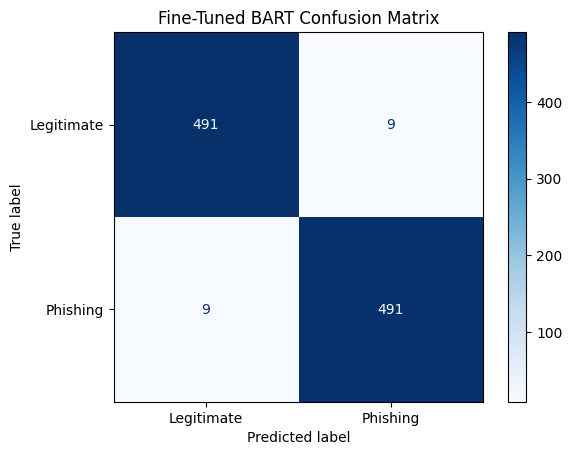

In [4]:
# ---------------------------
# 7) EVALUATE MODEL (Fixed)
# ---------------------------
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false" # Fixes the warning message

print("\nRunning Prediction on Test Set...")
preds = trainer.predict(encoded_test_dataset)

# --- FIX: Handle tuple output for Prediction ---
# Check if predictions is a tuple (common in BART/T5)
if isinstance(preds.predictions, tuple):
    # The first element [0] is the logits (scores)
    prediction_logits = preds.predictions[0]
else:
    prediction_logits = preds.predictions

# Now use the clean logits for argmax
y_pred = np.argmax(prediction_logits, axis=1)
y_true = preds.label_ids

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred, digits=4))

# ---------------------------
# 8) CONFUSION MATRIX (Fixed)
# ---------------------------

# FIX: We pass labels=[0, 1] to ensure the matrix is always 2x2, 
# even if the model only predicted one class or the test set only has one class.
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Fine-Tuned BART Confusion Matrix")
plt.show()

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load from the directory you just saved to
loaded_tokenizer = AutoTokenizer.from_pretrained("./final_phishing_bart_model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("./final_phishing_bart_model")

print("Model loaded successfully!")

You passed along `num_labels=3` with an incompatible id to label map: {'0': 'LABEL_0', '1': 'LABEL_1'}. The number of labels will be overwritten to 2.


Model loaded successfully!


In [7]:
# ---------------------------
# 9) INFERENCE ON NEW TEXT
# ---------------------------
import torch
import torch.nn.functional as F

# 1. Define the variable for your new text
new_text = "scan this link and send your payment as you are in suspect of a fraud"

# 2. Define the inference function
def predict_phishing(text, model, tokenizer, device):
    model.eval() # Set model to evaluation mode
    
    # Tokenize the input text
    # We use return_tensors="pt" to get PyTorch tensors
    inputs = tokenizer(
        text, 
        return_tensors="pt", 
        truncation=True, 
        max_length=256,
        padding=True
    )
    
    # Move inputs to the same device as the model (GPU or CPU)
    inputs = {key: val.to(device) for key, val in inputs.items()}
    
    # Run inference
    with torch.no_grad(): # Disable gradient calculation for speed
        outputs = model(**inputs)
        
    # Get logits (raw scores)
    logits = outputs.logits
    
    # Handle tuple output (if applicable)
    if isinstance(logits, tuple):
        logits = logits[0]

    # Convert logits to probabilities using Softmax
    probs = F.softmax(logits, dim=1)
    
    # Get the predicted class index (0 or 1)
    pred_index = torch.argmax(probs, dim=1).item()
    
    # Map to label
    labels_map = {0: "Legitimate", 1: "Phishing"}
    prediction_label = labels_map[pred_index]
    confidence = probs[0][pred_index].item()
    
    return prediction_label, confidence, probs[0]

# 3. Run the prediction
# Ensure device is defined (from previous steps)
device = "cuda" if torch.cuda.is_available() else "cpu"

label, score, all_probs = predict_phishing(new_text, model, tokenizer, device)

# 4. Print the results
print("-" * 30)
print(f"Input Text: {new_text}")
print("-" * 30)
print(f"Prediction: {label.upper()}")
print(f"Confidence: {score:.2%}")
print("-" * 30)
print(f"Detailed Probabilities:")
print(f"  Legitimate: {all_probs[0]:.4f}")
print(f"  Phishing:   {all_probs[1]:.4f}")
print("-" * 30)

------------------------------
Input Text: scan this link and send your payment as you are in suspect of a fraud
------------------------------
Prediction: PHISHING
Confidence: 99.92%
------------------------------
Detailed Probabilities:
  Legitimate: 0.0008
  Phishing:   0.9992
------------------------------
